### **Downloading Data**

In [3]:
!pip install -q kaggle

In [5]:
from google.colab import files
files.upload()


import os
os.makedirs('/root/.config/kaggle', exist_ok=True)


os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')

os.chmod('/root/.config/kaggle/kaggle.json', 600)

import kaggle
kaggle.api.authenticate()

kaggle.api.dataset_download_files(
    'smaranjitghose/corn-or-maize-leaf-disease-dataset',
    path='.',
    unzip=True
)

print("Dataset downloaded successfully!")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/smaranjitghose/corn-or-maize-leaf-disease-dataset
Dataset downloaded successfully!


### **Data Splitting**

In [6]:
import os
import shutil
from sklearn.model_selection import train_test_split

data_dir = './data'
train_dir = './train'
test_dir = './test'
val_dir = './val'

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)

        train_images, test_images = train_test_split(images, test_size=0.2, random_state=42)
        train_images, val_images = train_test_split(train_images, test_size=0.2, random_state=42)

        # Ensure class subdirectories exist in train, val, and test folders
        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

        # Copy images to train, val, and test directories
        for image in train_images:
            shutil.copy(os.path.join(class_path, image), os.path.join(train_dir, class_name, image))

        for image in val_images:
            shutil.copy(os.path.join(class_path, image), os.path.join(val_dir, class_name, image))

        for image in test_images:
            shutil.copy(os.path.join(class_path, image), os.path.join(test_dir, class_name, image))

### **Sample Images in Dataset**

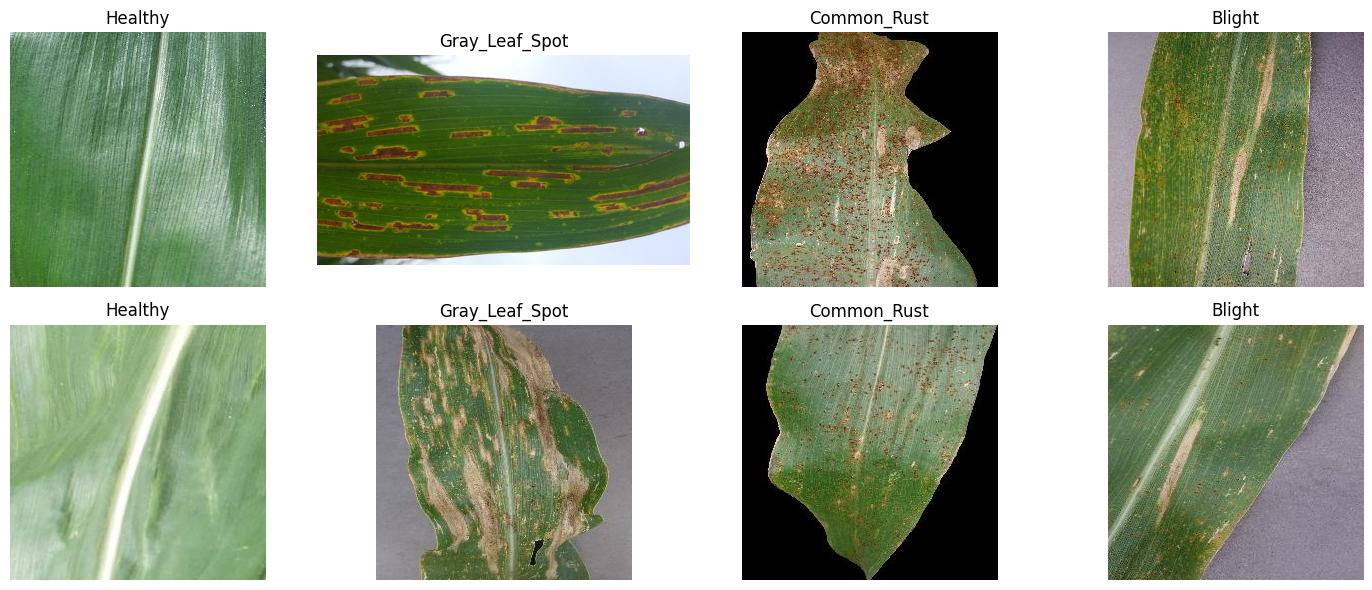

In [8]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image

# Path to your train folder
train_dir = "train"


classes = os.listdir(train_dir)

# Create a figure with 2 rows and 4 columns
fig, axes = plt.subplots(2, 4, figsize=(15, 6))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)


    sample_imgs = random.sample(images, 2)

    for j, img_name in enumerate(sample_imgs):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        # Plot in 2x4 grid
        ax = axes[j, i]
        ax.imshow(img)
        ax.set_title(f"{class_name}", fontsize=12)
        ax.axis("off")

plt.tight_layout()
plt.show()
